In [1]:
from google.colab import files
uploaded=files.upload()

Saving spam_ham_dataset_500.csv to spam_ham_dataset_500.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
sns.set_style("whitegrid")

In [3]:
df=pd.read_csv("/content/spam_ham_dataset_500.csv")

In [4]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,id,subject,message,sender,date,label
0,1,Interview confirmation,This email confirms your interview appointment...,team@project.org,2025-07-03,ham
1,2,Office announcement,Here is the updated travel itinerary for your ...,admin@university.edu,2026-07-16,ham
2,3,Documents for review,Here is the updated travel itinerary for your ...,admin@university.edu,2026-04-24,ham
3,4,Claim your exclusive reward today,A free gift has been reserved for you. Click t...,winner@special-prize.net,2026-04-18,spam
4,5,Limited time investment opportunity,Your account has been selected for a special r...,bonus@offers-mail.com,2025-01-24,spam


In [5]:
print("\nDATASET SHAPE")
print(df.shape)
print("\nCOLUMN NAMES")
print(df.columns)
print("\nDATA TYPES")
print(df.dtypes)
print("\nDATASET INFORMATION")
print(df.info())
print("\nSTATISTICAL SUMMARY")
print(df.describe())
print("\nMISSING VALUES")
print(df.isnull().sum())
print("\nDUPLICATE ROWS")
print(df.duplicated().sum())


DATASET SHAPE
(500, 6)

COLUMN NAMES
Index(['id', 'subject', 'message', 'sender', 'date', 'label'], dtype='object')

DATA TYPES
id          int64
subject    object
message    object
sender     object
date       object
label      object
dtype: object

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       500 non-null    int64 
 1   subject  500 non-null    object
 2   message  500 non-null    object
 3   sender   500 non-null    object
 4   date     500 non-null    object
 5   label    500 non-null    object
dtypes: int64(1), object(5)
memory usage: 23.6+ KB
None

STATISTICAL SUMMARY
               id
count  500.000000
mean   250.500000
std    144.481833
min      1.000000
25%    125.750000
50%    250.500000
75%    375.250000
max    500.000000

MISSING VALUES
id         0
subject    0
message    0
sender     0
date       0
label   

In [6]:
df['subject'] = df['subject'].fillna('')
df['message'] = df['message'].fillna('')
df['sender'] = df['sender'].fillna('Unknown')

df['message_length'] = df['message'].str.len()
df['subject_length'] = df['subject'].str.len()
df['word_count'] = df['message'].str.split().str.len()

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['spam_flag'] = df['label'].map({'ham': 0, 'spam': 1})

print("Feature creation completed.")
display(df.head())

Feature creation completed.


,id,subject,message,sender,date,label,message_length,subject_length,word_count,spam_flag
0,1,Interview confirmation,This email confirms your interview appointment...,team@project.org,2025-07-03,ham,109,22,15,0
1,2,Office announcement,Here is the updated travel itinerary for your ...,admin@university.edu,2026-07-16,ham,85,19,15,0
2,3,Documents for review,Here is the updated travel itinerary for your ...,admin@university.edu,2026-04-24,ham,85,20,15,0
3,4,Claim your exclusive reward today,A free gift has been reserved for you. Click t...,winner@special-prize.net,2026-04-18,spam,88,33,18,1
4,5,Limited time investment opportunity,Your account has been selected for a special r...,bonus@offers-mail.com,2025-01-24,spam,99,35,14,1


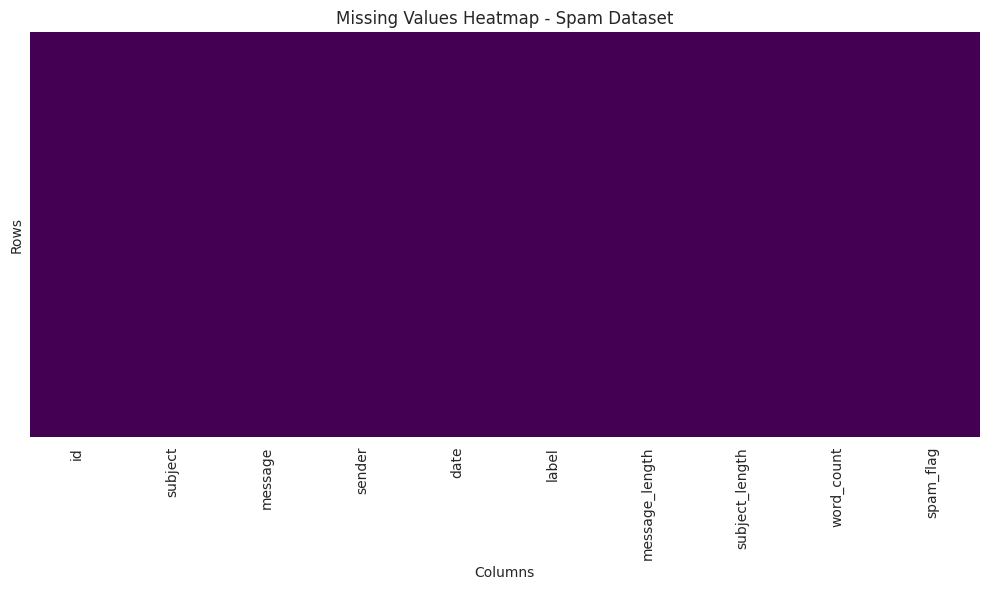

In [7]:
fig1 = plt.figure(figsize=(10, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)
plt.title("Missing Values Heatmap - Spam Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

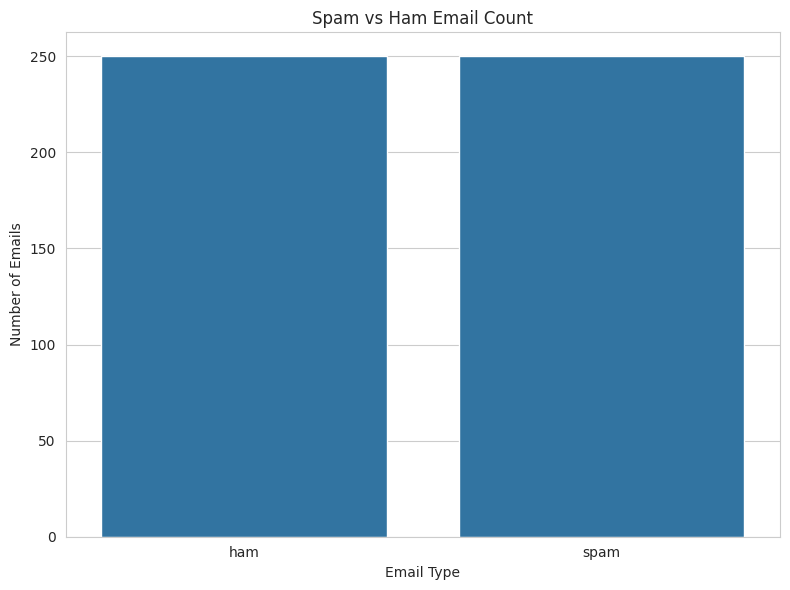


Email class counts:
label
ham     250
spam    250
Name: count, dtype: int64


In [8]:
fig2 = plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x='label'
)
plt.title("Spam vs Ham Email Count")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.show()

print("\nEmail class counts:")
print(df['label'].value_counts())

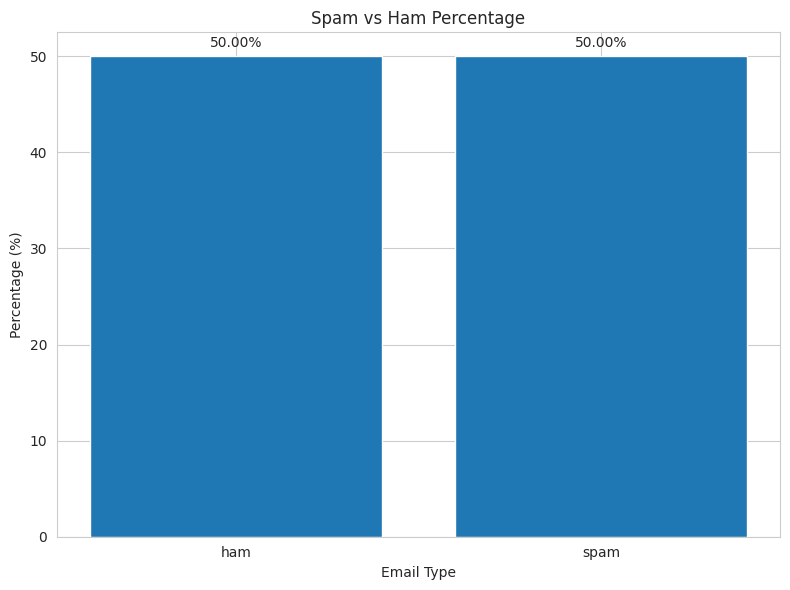

In [9]:
fig3 = plt.figure(figsize=(8, 6))

label_percentage = df['label'].value_counts(normalize=True) * 100
plt.bar(
    label_percentage.index,
    label_percentage.values
)
plt.title("Spam vs Ham Percentage")
plt.xlabel("Email Type")
plt.ylabel("Percentage (%)")

for i, value in enumerate(label_percentage.values):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha='center'
    )
plt.tight_layout()
plt.show()

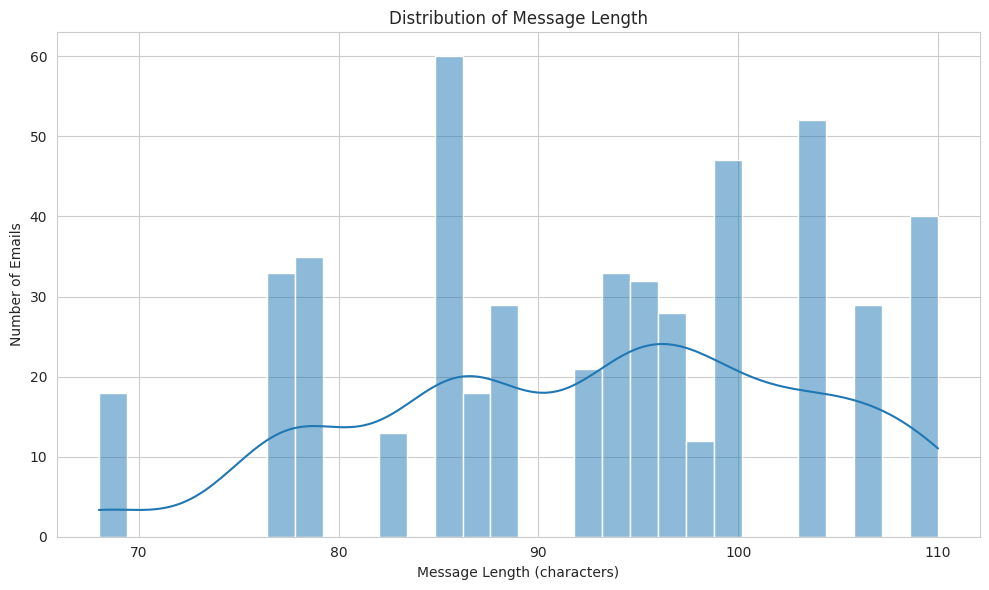

In [10]:
fig4 = plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='message_length',
    bins=30,
    kde=True
)
plt.title("Distribution of Message Length")
plt.xlabel("Message Length (characters)")
plt.ylabel("Number of Emails")
plt.tight_layout()

plt.show()

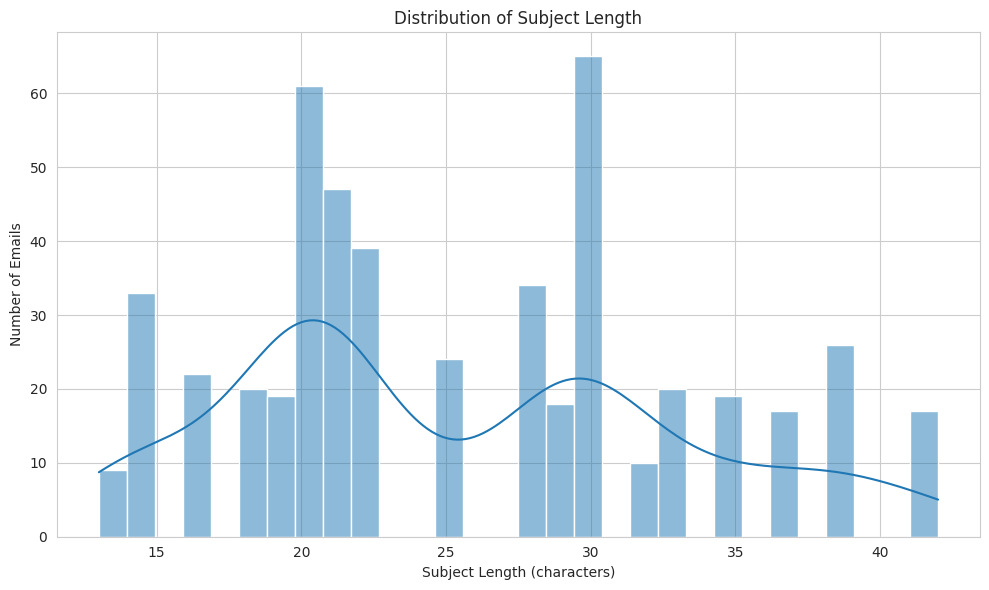

In [11]:
fig5 = plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='subject_length',
    bins=30,
    kde=True
)
plt.title("Distribution of Subject Length")
plt.xlabel("Subject Length (characters)")
plt.ylabel("Number of Emails")
plt.tight_layout()

plt.show()

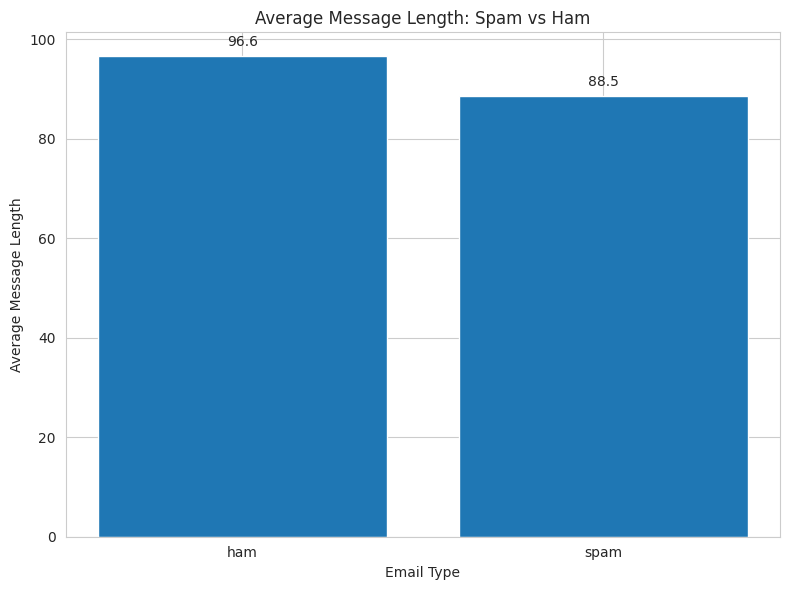

Average message length:
label
ham     96.584
spam    88.540
Name: message_length, dtype: float64


In [12]:
fig6 = plt.figure(figsize=(8, 6))

avg_length = df.groupby('label')['message_length'].mean()

plt.bar(
    avg_length.index,
    avg_length.values
)
plt.title("Average Message Length: Spam vs Ham")
plt.xlabel("Email Type")
plt.ylabel("Average Message Length")

for i, value in enumerate(avg_length.values):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}",
        ha='center'
    )
plt.tight_layout()
plt.show()

print("Average message length:")
print(avg_length)

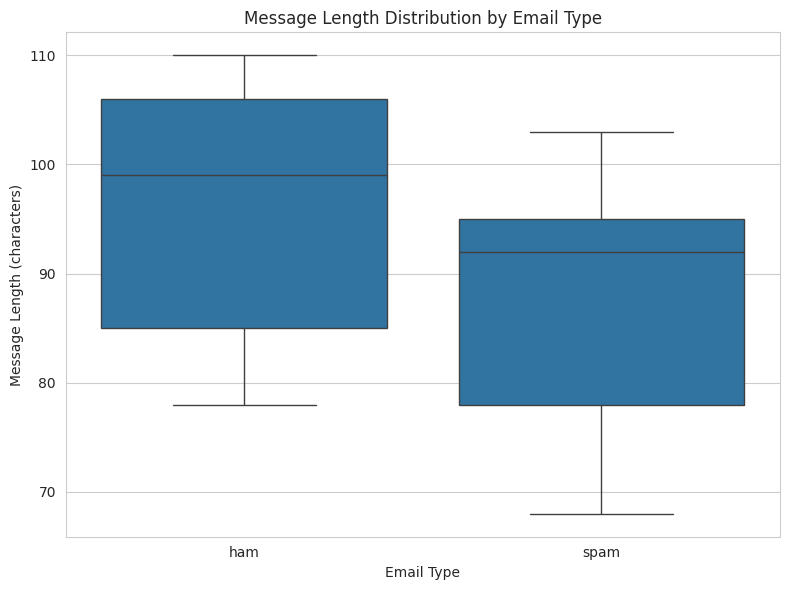

In [13]:
fig7 = plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='label',
    y='message_length'
)
plt.title("Message Length Distribution by Email Type")
plt.xlabel("Email Type")
plt.ylabel("Message Length (characters)")
plt.tight_layout()

plt.show()

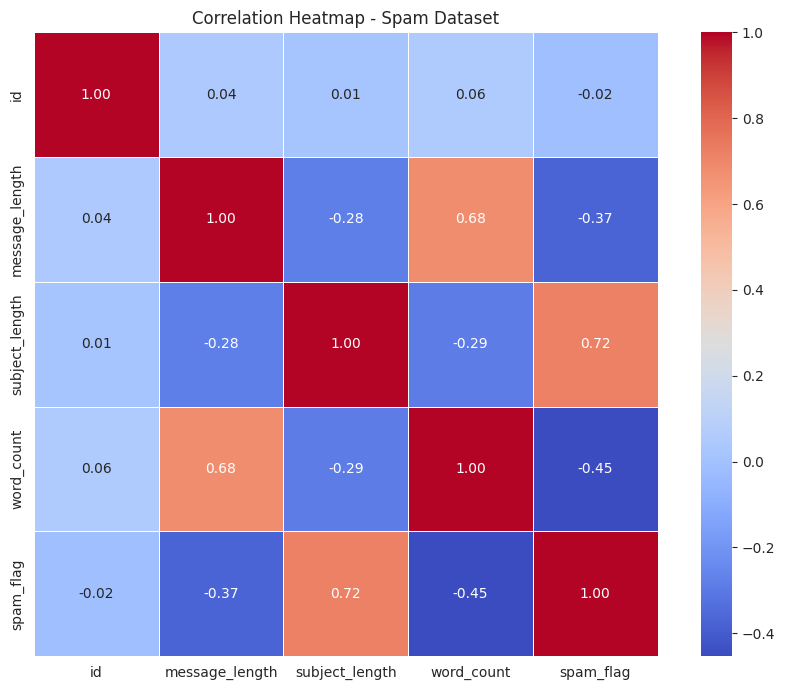

In [14]:
fig8= plt.figure(figsize=(9, 7))

numeric_cols = [
    'id',
    'message_length',
    'subject_length',
    'word_count',
    'spam_flag'
]
corr_matrix = df[numeric_cols].corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap - Spam Dataset")
plt.tight_layout()

plt.show()

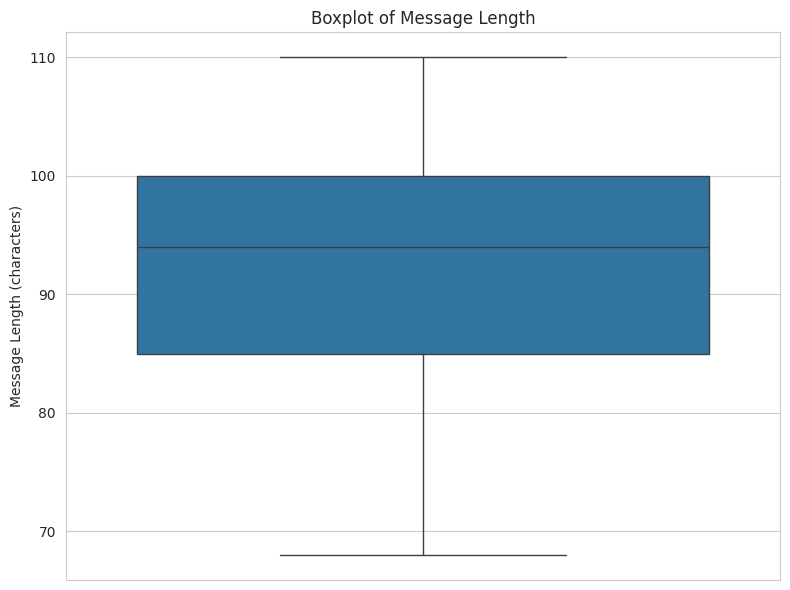

In [15]:
fig9= plt.figure(figsize=(8, 6))

sns.boxplot(
    y=df['message_length']
)

plt.title("Boxplot of Message Length")
plt.ylabel("Message Length (characters)")
plt.tight_layout()

plt.show()

In [16]:
pdf = PdfPages("Spam_EDA_Report.pdf")

# Save every graph as a separate PDF page
pdf.savefig(fig1, bbox_inches='tight')
pdf.savefig(fig2, bbox_inches='tight')
pdf.savefig(fig3, bbox_inches='tight')
pdf.savefig(fig4, bbox_inches='tight')
pdf.savefig(fig5, bbox_inches='tight')
pdf.savefig(fig6, bbox_inches='tight')
pdf.savefig(fig7, bbox_inches='tight')
pdf.savefig(fig8, bbox_inches='tight')
pdf.savefig(fig9, bbox_inches='tight')


pdf.close()

print("Spam_EDA_Report.pdf created successfully!")
print("Total graph pages: 15")

Spam_EDA_Report.pdf created successfully!
Total graph pages: 15


In [17]:
from google.colab import files

files.download("Spam_EDA_Report.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>